<div style="width: 100%; clear: both;">
<div style="float: left; width: 50%;">
<img src="https://www.uoc.edu/content/dam/news/images/noticies/2016/202-nova-marca-uoc.jpg" align="left" width="45%">
</div>
<div style="float: right; width: 50%;">
<p style="margin: 0; padding-top: 22px; text-align:right;">M2.891 · Aprendizaje automático · PEC4</p>
<p style="margin: 0; text-align:right;">2025-1· Máster universitario en Ciencia de datos (Data science)</p>
<p style="margin: 0; text-align:right; padding-button: 100px;">Estudios de Informática, Multimedia y Telecomunicación</p>
</div>
</div>
<div style="width:100%;">&nbsp;</div>

# **PEC 4: Combinación de Modelos**

## **Objetivo**
Esta cuarta Práctica de Evaluación Continua (PEC 4) tiene como objetivo principal consolidar los conocimientos adquiridos en las PECs anteriores (introducción al aprendizaje automático, análisis exploratorio de datos, métodos supervisados y no supervisados) e introducir y profundizar en técnicas avanzadas de Ensemble Learning (Aprendizaje por Conjuntos).

Al finalizar esta PEC, deberías ser capaz de:

* Implementar y comparar diversas técnicas de ensemble learning (p. ej., Bagging/Random Forest, Boosting -AdaBoost, Gradient Boosting-, Stacking y cascading) sobre un conjunto de datos específico.
* Analizar y explicar cómo los hiperparámetros clave de los métodos ensemble influyen en su comportamiento y rendimiento.
* Evaluar y comparar la importancia de las características (feature importance) obtenida a través de diferentes modelos ensemble.
* Justificar cuándo y por qué un método ensemble podría ser preferible a otro, o a un modelo individual (conectando con conceptos como el trade-off sesgo-varianza).
* Aplicar correctamente metodologías de validación (como validación cruzada) para la evaluación y comparación robusta de los modelos ensemble.

## **Conjunto de datos**
Una compañía opera un parque eólico crítico con 3000 turbinas y busca optimizar sus costes operativos y asegurar la continuidad del servicio.

Actualmente, la estrategia de mantenimiento es ineficiente: o bien es reactiva (arreglar cuando se rompe, lo cual es muy costoso) o preventivo-fija (revisar cada X meses, lo cual desperdicia recursos en máquinas sanas). Vuestro objetivo es desarrollar un modelo de Mantenimiento Predictivo basado en los datos de los sensores instalados en las turbinas.

El dataset (`wind_turbine_data.csv`) contiene lecturas de sensores de vibración, temperatura, eléctricos y ambientales. Los valores de los sensores ya han sido transformados por el equipo de ingeniería de datos. Se presentan como **z-scores (estandarizados)**.  Esto significa que veréis valores positivos y negativos centrados en cero. Un valor de `0` indica que el sensor está en su media histórica operativa; valores altos (positivos o negativos) indican desviaciones anómalas respecto al comportamiento normal. Por ejemplo, una temperatura "negativa" no significa bajo cero absoluto, sino que es más baja que el promedio habitual de funcionamiento.

Las variables del dataset se agrupan por subsistemas de la turbina:

| Subsistema | Variables (Sensores) | Descripción |
| :--- | :--- | :--- |
| **Target** | `Operational_Status` | Variable a predecir:<br>**0: Normal** (Funcionamiento óptimo).<br>**1: Warning** (Alerta de Mantenimiento. Requiere visita).<br>**2: Failure** (Fallo Crítico. Parada inmediata necesaria). |
| **Generador** | `Gen_Avg_RPM`<br>`Gen_Output_Voltage`<br>`Gen_Coil_Temp` | Revoluciones por minuto, voltaje de salida y temperatura del bobinado. |
| **Red Eléctrica** | `Grid_Frequency_Hz` | Frecuencia de sincronización con la red eléctrica. |
| **Rotor y Palas** | `Rotor_Blade_Angle_1`<br>`Rotor_Blade_Angle_2`<br>`Rotor_Shaft_Vibration`<br>`Rotor_Wind_Speed` | Ángulos de las palas, vibración del eje principal y velocidad del viento incidente.<br>|
| **Hidráulica** | `Hydraulic_Oil_Pressure`<br>`Hydraulic_Oil_Temp`<br>`Hydraulic_Tank_Level` | Estado del sistema hidráulico (frenos y orientación). |
| **Caja de Cambios** | `Gearbox_Bearing_Temp`<br>`Gearbox_Vibration_X`<br>`Gearbox_Vibration_Y` | Temperatura de rodamientos y vibración en ejes X/Y. |
| **Ambiental** | `Amb_Ext_Temp`<br>`Amb_Humidity`<br>`Amb_Wind_Turbulence`<br>`Tower_Oscillation` | Condiciones externas y oscilación de la torre. |
| **Metadatos** | `Installation_Region`<br>`Turbine_Model` | Región geográfica y modelo de la máquina. |

El objetivo no es solo implementar los algoritmos, sino sobre todo analizar en profundidad su comportamiento, comparar sus resultados y justificar tus conclusiones basándote siempre en la evidencia obtenida de tus propios experimentos y resultados numéricos/gráficos. Se valorará especialmente la capacidad crítica y la profundidad de tus interpretaciones.

<div style="background-color: #dff0d8; color: #3c763d; padding: 10px; border: 1px solid #d6e9c6; border-radius: 4px;">
<strong>Nombre y apellidos: JULIO UBEDA QUESADA</strong>
</div>

## **Funciones auxiliares**

He creado cinco funciones que me permitirán **evaluar rápidamente la calidad y estructura de los datos** antes de realizar análisis más detallados:

- La primera, **`describe_df()`**, genera un resumen completo del DataFrame, mostrando su forma, tipos de datos, valores nulos, número de valores únicos y estadísticas básicas para las columnas numéricas.
- La segunda, **`frequency_table()`**, genera una tabla de frecuencias y porcentajes para una lista de columnas dadas, lo que me permite obtener un resumen rápido de la distribución de los valores en cada columna.
- La tercera, **`correlation_matrix()`**, genera una matriz de correlación para una lista de columnas dadas, lo que me permite obtener un resumen rápido de la correlación entre las variables.
- La cuarta, **`detect_outliers()`**, detecta valores atípicos en todas las columnas numéricas usando el método IQR.
- La quinta, **`evaluate_model()`**, evalúa el rendimiento de los modelos.

In [58]:
def describe_df(data): 
    """
    Proporciona un resumen detallado del DataFrame, incluyendo un mensaje inicial con su forma,
    estadísticas, valores nulos y los dos valores más frecuentes por columna.
    """
    # Mensaje informativo antes de la tabla
    print(f"El dataframe tiene {data.shape[1]} columnas y {data.shape[0]} filas.\n")

    total = len(data)
    
    # Base del resumen
    summary = pd.DataFrame({
        'Column': data.columns,
        'Data Type': data.dtypes.astype(str),
        'Non-null Count': data.count().values,
        '% Null Values': ((data.isnull().sum() / total) * 100).round(2).values,
        'Unique Values': data.nunique().values
    })

    # Estadísticas para columnas numéricas
    numeric_cols = data.select_dtypes(include=['number']).columns
    if not numeric_cols.empty:
        describe_stats = data[numeric_cols].describe().T
        describe_stats = describe_stats.rename(columns={'50%': 'median'})[
            ['mean', 'median', 'std', 'min', '25%', '75%', 'max']
        ]
        describe_stats.reset_index(inplace=True)
        describe_stats.rename(columns={'index': 'Column'}, inplace=True)

        summary = pd.merge(summary, describe_stats, on='Column', how='left')

    return summary

def frequency_table(df, columns):
    """
    Genera un único DataFrame con el análisis de frecuencias y porcentajes
    para una lista de columnas dadas.
    """
    results = []
    
    for col in columns:
        # Calcular recuento y porcentaje
        counts = df[col].value_counts(dropna=False)
        percentages = (df[col].value_counts(normalize=True, dropna=False) * 100).round(2)
        
        # Crear DataFrame temporal para la columna actual
        temp_df = pd.DataFrame({
            'Variable': col,
            'Categoría': counts.index,
            'Recuento': counts.values,
            'Porcentaje (%)': percentages.values
        })
        
        results.append(temp_df)
    
    # Concatenar todos los resultados en una sola tabla
    final_table = pd.concat(results, ignore_index=True)
    
    return final_table


def correlation_analysis(df, exclude_cols, save_path=None):
    """
    Genera un análisis de correlación entre variables numéricas.
    """
    # Seleccionar datos solo numéricos
    df_numeric = df.select_dtypes(include=[np.number]).drop(columns=[c for c in exclude_cols if c in df.columns], errors='ignore')
    corr_matrix = df_numeric.corr()
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
    
    # Heatmap
    plt.figure(figsize=(12, 8))
    sns.heatmap(corr_matrix, mask=mask, cmap="RdBu_r", center=0, annot=True, fmt=".2f", linewidths=.5)
    plt.title("Matriz de Correlación: Interdependencia entre Sensores", fontsize=15, pad=20)
    
    if save_path:
        directory = os.path.dirname(save_path)
        if directory and not os.path.exists(directory): os.makedirs(directory)
        plt.savefig(save_path, bbox_inches='tight', dpi=300)
    plt.show()

    # Extraer pares únicos
    pairs_list = []
    cols = corr_matrix.columns
    for i in range(len(cols)):
        for j in range(i): 
            val = corr_matrix.iloc[i, j]
            pairs_list.append({
                'Var1': cols[i],
                'Var2': cols[j],
                'Corr': val,
                'Abs_Corr': abs(val)
            })
    
    pairs_df = pd.DataFrame(pairs_list)

    # Clasificación según tus umbrales estrictos
    def clasificar(r):
        if r >= 0.7: return 'Fuerte'
        elif 0.3 <= r < 0.7: return 'Moderada'
        else: return 'Débil'

    pairs_df['Tipo'] = pairs_df['Abs_Corr'].apply(clasificar)
    
    # Selección de las "Top 3" de cada categoría 
    fuertes = pairs_df[pairs_df['Tipo'] == 'Fuerte'].sort_values('Abs_Corr', ascending=False).head(3)
    moderadas = pairs_df[pairs_df['Tipo'] == 'Moderada'].sort_values('Abs_Corr', ascending=False).head(3)
    debiles = pairs_df[pairs_df['Tipo'] == 'Débil'].sort_values('Abs_Corr', ascending=False).head(3)

    resumen = pd.concat([fuertes, moderadas, debiles]).reset_index(drop=True)
    
    return resumen[['Tipo', 'Var1', 'Var2', 'Corr']]


def detect_outliers(df):
    """
    Detecta valores atípicos en todas las columnas numéricas usando el método IQR.
    Retorna un DataFrame con el recuento y el porcentaje de outliers por columna.
    """
    # Seleccionar solo columnas numéricas
    numeric_cols = df.select_dtypes(include=['number']).columns
    outlier_data = []

    for col in numeric_cols:
        # Calcular Q1 (percentil 25) y Q3 (percentil 75)
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        
        # Definir límites (Estándar de Tukey)
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        # Identificar outliers
        outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
        count = len(outliers)
        percentage = (count / len(df)) * 100
        
        outlier_data.append({
            'Columna': col,
            'Outliers': count,
            'Porcentaje (%)': f"{percentage:.2f}%",
            'Límite Inferior': f"{lower_bound:.2f}",
            'Límite Superior': f"{upper_bound:.2f}",
            'Mínimo Real': f"{df[col].min():.2f}",
            'Máximo Real': f"{df[col].max():.2f}"
        })

    # Crear DataFrame de resultados
    summary = pd.DataFrame(outlier_data)
    
    # Ordenar por mayor número de outliers
    return summary.sort_values(by='Outliers', ascending=False).reset_index(drop=True)


def evaluate_model(name, y_true, y_pred):
    """
    Evalúa el desempeño de un modelo de clasificación.
    """
    print(f"\n{name}")
    print(classification_report(y_true, y_pred, digits=3))

## **1. Carga, Análisis Exploratorio Crítico y Limpieza de Datos (1 punto)**

<div style="background-color: #d9edf7; color: #31708f; padding: 10px; border: 1px solid #bce8f1; border-radius: 4px;">
<h4>Implementación:</h4>

1. Carga el dataset <code>wind_turbine_data.csv</code>.
2. Análisis Exploratorio de Datos (EDA) Asistido por I.A.:
    - Utiliza una herramienta de I.A. Generativa (ej. ChatGPT, Gemini, Copilot, Calude, etc.) para asistirte en la realización de un EDA exhaustivo.
    - Revisa la información general del dataset (tipos de datos, variables categóricas/numéricas).
    - Analiza los valores atípicos, los patrones de correlación y la distribución de la variable objetivo (`Operational_Status`).
3. **Análisis Crítico:** Basándote únicamente en los hallazgos de tu EDA, discute los principales desafíos que anticipas que este dataset podría presentar para los modelos de clasificación estándar. Identifica las variables más importantes para la clasificación.
4. Preparación y Justificación de Datos:
    - Realiza las transformaciones de datos necesarias para la Clasificación.
    - Justifica tus decisiones sobre: Codificación de variables categóricas, Escalado/Normalización de variables numéricas, y manejo de variables con patrones de distribución no lineales (si decides transformarlas).
    - Recuerda aplicar la división correcta entre Train/Test sets y evitar la fuga de datos. Usa siempre com semilla el número 42.
5. **Análisis Crítico: Reflexión sobre el Uso de I.A. Generativa**
    - Se claro y honesto: ¿Qué herramienta de I.A. has usado y para qué tareas específicas?
    - Identifica las sugerencias erróneas o engañosa que la I.A. te haya dado durante el EDA o la preparación de datos. ¿Cómo las has corregido?
    - Concluye: ¿Cuál es el principal riesgo de delegar el análisis completamente a una I.A.?
</div>

### **1.1. Importar librerías y carga del dataset `wind_turbine_data.cscv`**

In [117]:
# Proporciona funciones para interactuar con el sistema operativo (como rutas de archivos)
import os  

# Permite modificar aspectos del entorno de ejecución de Python, como la lista de rutas de búsqueda de módulos (sys.path)
import sys 

# Sube un nivel desde /PEC/
root_dir = os.path.abspath('..')  
sys.path.append(root_dir)

# Librerías necesarias para el análisis de datos y visualización
import pandas as pd
pd.set_option('display.float_format', '{:.2f}'.format)
pd.set_option('display.max_columns', None)

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Librerías necesarias para el preprocesamiento de datos
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler

# Librerías necesarias para el entrenamiento de modelos
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

# Librerías necesarias para la evaluación de modelos y tunning
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import GridSearchCV


# Librerías necesarias para el entrenamiento y evaluación de modelos
from sklearn.model_selection import train_test_split


Carga el dataset <code>wind_turbine_data.csv</code>.

In [60]:
# Ruta del dataset
path = r"..\Data\wind_turbine_data.csv"

# Cargar el dataset
df = pd.read_csv(path)

df.head()

,Installation_Region,Turbine_Model,Gen_Avg_RPM,Gen_Output_Voltage,Gen_Coil_Temp,Grid_Frequency_Hz,Rotor_Blade_Angle_1,Rotor_Blade_Angle_2,Rotor_Wind_Speed,Rotor_Shaft_Vibration,Rotor_Shaft_Vibration_Redundant,Hydraulic_Oil_Pressure,Hydraulic_Oil_Temp,Hydraulic_Tank_Level,Gearbox_Bearing_Temp,Gearbox_Vibration_X,Gearbox_Vibration_Y,Amb_Ext_Temp,Amb_Humidity,Amb_Wind_Turbulence,Tower_Oscillation,Tower_Fatigue_Index,System_Efficiency_Calc,Operational_Status
0,South_Plains,Turbine_Model_C,1.82,0.91,0.46,-1.03,2.10,1.92,-1.74,-2.66,-2.66,-0.49,0.78,-2.31,1.90,-1.39,4.43,0.70,-1.45,2.35,0.65,-0.37,0.36,2
1,South_Plains,Turbine_Model_B,4.23,-0.43,4.73,1.00,-3.97,2.44,0.85,-3.31,-3.31,0.71,-1.07,-0.95,-5.08,-1.53,0.86,0.03,-0.05,0.19,1.08,0.18,3.46,2
2,High_Mountains,Turbine_Model_D,0.86,0.98,0.04,-0.37,-4.95,-0.57,2.23,-2.31,-2.31,-0.12,0.89,1.91,-5.96,-2.22,-3.32,-1.35,0.28,3.00,0.34,-0.46,-0.05,1
3,South_Plains,Turbine_Model_D,1.50,1.77,1.31,1.31,1.17,0.51,0.67,0.85,0.85,-3.18,-0.64,-0.40,-1.04,-1.00,3.29,0.12,1.10,1.35,-0.64,1.44,1.06,1
4,High_Mountains,Turbine_Model_B,-0.02,-1.57,-0.82,2.35,-1.00,0.32,-1.54,-1.20,-1.20,-2.34,0.13,-1.70,3.03,0.58,4.14,-0.17,0.23,1.36,1.41,-0.56,0.69,0


### **1.2. Análisis Exploratorio de Datos (EDA)**

A continuación, se describe el análisis exploratorio de datos (EDA) que se ha realizado para el dataset de turbinas eólicas. Para ello me he apoyado en la herramienta de I.A. Generativa ChatGPT y Claude para asistirme en la realización de un EDA exhaustivo.

#### **1.2.1. Información general del dataset**

El dataset está compuesto por **3000 observaciones y 24 variables**, de las cuales:

* **22 son variables numéricas continuas**, correspondientes a sensores físicos de la turbina.
* **2 son variables categóricas** (`Installation_Region`, `Turbine_Model`).
* **1 variable objetivo** (`Operational_Status`) con tres clases.

No se detectan **valores nulos** en ninguna columna, lo que indica una fase previa de limpieza adecuada por parte del equipo de ingeniería de datos y evita la necesidad de imputaciones.

Las variables numéricas presentan:

* Media cercana a 0 y desviación típica cercana a 1–2 en la mayoría de los casos, lo cual confirma que han sido **estandarizadas mediante z-score**.
* Rangos amplios (mínimos y máximos extremos), lo que refleja **comportamientos anómalos reales** del sistema, especialmente relevantes para el objetivo de mantenimiento predictivo.

Un aspecto relevante es la existencia de la variable `Rotor_Shaft_Vibration_Redundant`, que parece duplicar exactamente la información de `Rotor_Shaft_Vibration`, lo que anticipa **redundancia informativa**.

In [61]:
describe_df(df)

El dataframe tiene 24 columnas y 3000 filas.



,Column,Data Type,Non-null Count,% Null Values,Unique Values,mean,median,std,min,25%,75%,max
0,Installation_Region,object,3000,0.00,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Turbine_Model,object,3000,0.00,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Gen_Avg_RPM,float64,3000,0.00,3000,-0.17,-0.23,1.99,-7.43,-1.54,1.12,8.85
3,Gen_Output_Voltage,float64,3000,0.00,3000,0.19,0.26,2.01,-7.02,-1.09,1.57,7.29
4,Gen_Coil_Temp,float64,3000,0.00,3000,0.02,0.04,1.99,-6.90,-1.29,1.42,6.10
5,Grid_Frequency_Hz,float64,3000,0.00,3000,0.57,0.62,2.00,-7.18,-0.70,1.85,7.80
6,Rotor_Blade_Angle_1,float64,3000,0.00,3000,0.34,0.32,1.99,-7.16,-1.03,1.67,8.44
7,Rotor_Blade_Angle_2,float64,3000,0.00,3000,0.00,-0.01,1.01,-3.60,-0.67,0.65,4.20
8,Rotor_Wind_Speed,float64,3000,0.00,3000,0.20,0.24,1.86,-7.13,-1.02,1.46,6.52
9,Rotor_Shaft_Vibration,float64,3000,0.00,3000,0.21,0.13,1.91,-6.64,-1.11,1.45,6.97


#### **1.2.2. Distribución de las variables categóricas y objetivo**

**Variables categóricas:**

* `Installation_Region` está **perfectamente balanceada** entre sus cuatro categorías (25% cada una), lo que evita sesgos geográficos en el entrenamiento.
* `Turbine_Model` presenta una distribución razonablemente equilibrada, aunque el modelo D está algo menos representado (17.7%).

Esto es positivo para la generalización de los modelos y permite analizar si ciertos modelos o regiones presentan mayor propensión a fallos.

**Variable objetivo (`Operational_Status`):**

La distribución es:

* **Normal (0): 49.67%**
* **Warning (1): 30.23%**
* **Failure (2): 20.10%**

Aunque no es un desbalance extremo, **sí existe una asimetría clara**, especialmente relevante porque la clase *Failure* es la más crítica desde el punto de vista operativo.

Esto anticipa que:

* Métricas como *accuracy* pueden ser engañosas. **¿Por que?**
* Será necesario prestar atención al *recall* de la clase 2 en fases posteriores. **¿Por que?**

In [62]:
cols_to_analyze = ['Installation_Region', 'Turbine_Model', 'Operational_Status']
df_frecuencias = frequency_table(df, cols_to_analyze)

# Mostrar el resultado
df_frecuencias

,Variable,Categoría,Recuento,Porcentaje (%)
0,Installation_Region,South_Plains,750,25.00
1,Installation_Region,High_Mountains,750,25.00
2,Installation_Region,Interior_Valley,750,25.00
3,Installation_Region,North_Coast,750,25.00
4,Turbine_Model,Turbine_Model_A,866,28.87
5,Turbine_Model,Turbine_Model_B,815,27.17
6,Turbine_Model,Turbine_Model_C,788,26.27
7,Turbine_Model,Turbine_Model_D,531,17.70
8,Operational_Status,0,1490,49.67
9,Operational_Status,1,907,30.23


#### **1.2.3. Correlaciones entre sensores**

El análisis de correlación revela varios patrones importantes:

* Existe una **correlación perfecta (ρ = 1.00)** entre:

  * `Rotor_Shaft_Vibration` y `Rotor_Shaft_Vibration_Redundant`.

Esto confirma que una de estas variables es completamente redundante y puede eliminarse sin pérdida de información.

* Se observan **correlaciones moderadas** entre:

  * Temperatura externa (`Amb_Ext_Temp`) y frecuencia de red (`Grid_Frequency_Hz`).
  * Temperatura del generador (`Gen_Coil_Temp`) y temperatura de rodamientos del gearbox.
  * RPM del generador y temperatura ambiente.

Estas relaciones reflejan **interdependencias físicas reales** entre subsistemas mecánicos, eléctricos y ambientales.

* El resto de correlaciones son débiles, lo que indica que:

  * La mayoría de sensores aportan **información complementaria**.
  * No existe multicolinealidad severa generalizada.

Este patrón favorece el uso de **modelos no lineales y ensembles**, capaces de explotar interacciones complejas.

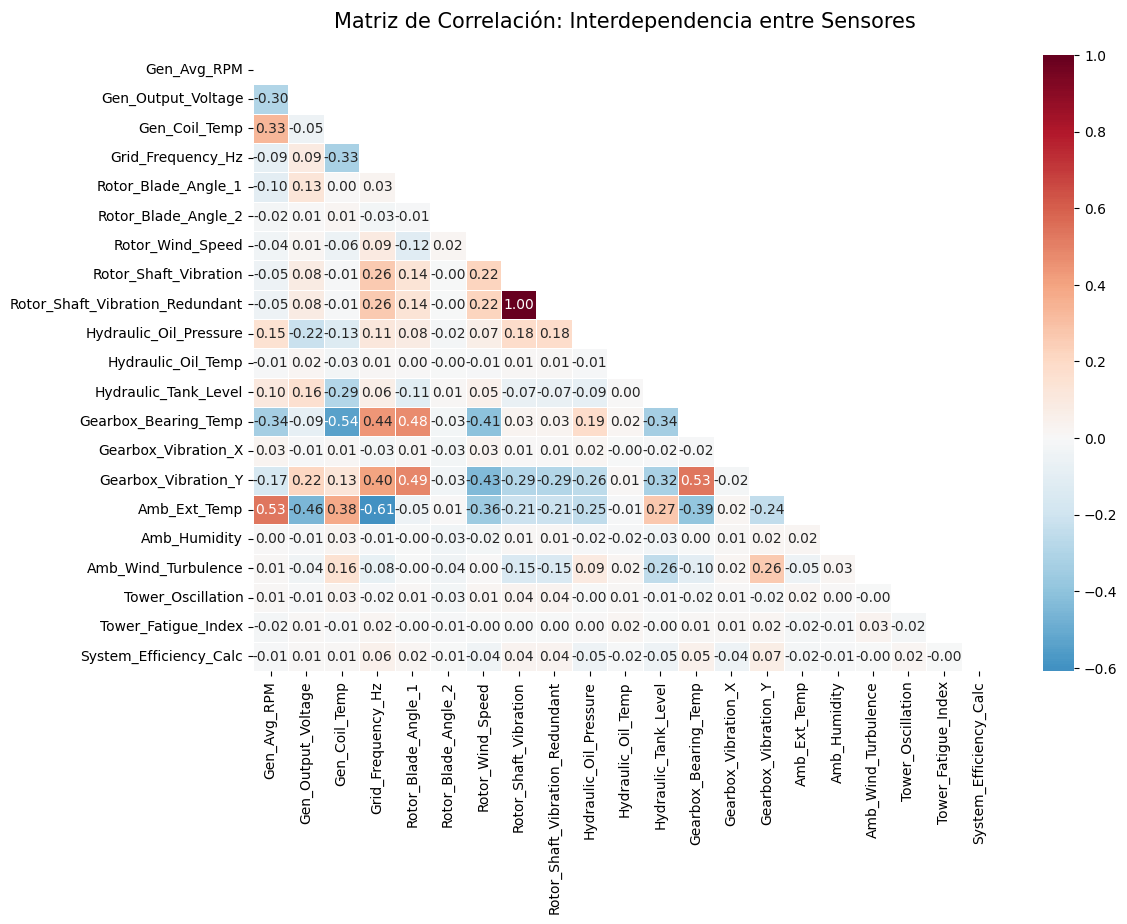

,Tipo,Var1,Var2,Corr
0,Fuerte,Rotor_Shaft_Vibration_Redundant,Rotor_Shaft_Vibration,1.00
1,Moderada,Amb_Ext_Temp,Grid_Frequency_Hz,-0.61
2,Moderada,Gearbox_Bearing_Temp,Gen_Coil_Temp,-0.54
3,Moderada,Amb_Ext_Temp,Gen_Avg_RPM,0.53
4,Débil,Gen_Output_Voltage,Gen_Avg_RPM,-0.30
5,Débil,Gearbox_Vibration_Y,Rotor_Shaft_Vibration,-0.29
6,Débil,Gearbox_Vibration_Y,Rotor_Shaft_Vibration_Redundant,-0.29


In [63]:
# Análisis de correlación
resumen_corr = correlation_analysis(
    df, 
    cols_to_analyze, 
    save_path=r'..\Visualizaciones\matriz_sensores.png'
)

resumen_corr

#### **1.2.4. Valores atípicos**

El análisis de *outliers* muestra que:

* La mayoría de variables presentan entre **0.7% y 1.8% de valores extremos**.
* Algunas variables críticas como:

  * `System_Efficiency_Calc`
  * `Gearbox_Bearing_Temp`
  * `Hydraulic_Oil_Pressure`
  * `Amb_Wind_Turbulence`

presentan colas largas, con valores muy alejados de los límites intercuartílicos.

Dado que:

* Las variables están en z-score.
* El contexto es **detección de fallos y comportamientos anómalos**,

estos outliers **no deben eliminarse**, ya que probablemente representan:

* Estados de degradación
* Condiciones previas a fallos
* Fallos críticos reales

Eliminar estos valores supondría **perder señal predictiva clave**, especialmente para la clase *Failure*.

In [64]:
# Revision de outliers
df_outliers = detect_outliers(df)
df_outliers

,Columna,Outliers,Porcentaje (%),Límite Inferior,Límite Superior,Mínimo Real,Máximo Real
0,System_Efficiency_Calc,168,5.60%,-2.95,2.87,-5.43,6.77
1,Gearbox_Vibration_Y,55,1.83%,-5.70,8.36,-12.13,12.81
2,Grid_Frequency_Hz,54,1.80%,-4.52,5.67,-7.18,7.80
3,Hydraulic_Oil_Pressure,48,1.60%,-5.30,4.01,-7.57,7.54
4,Gearbox_Bearing_Temp,47,1.57%,-6.43,7.22,-8.20,10.57
5,Hydraulic_Tank_Level,46,1.53%,-5.56,4.32,-8.58,6.21
6,Amb_Wind_Turbulence,42,1.40%,-3.74,5.39,-9.80,7.86
7,Gen_Output_Voltage,30,1.00%,-5.07,5.56,-7.02,7.29
8,Tower_Fatigue_Index,29,0.97%,-2.68,2.65,-3.59,3.86
9,Rotor_Blade_Angle_2,29,0.97%,-2.65,2.64,-3.60,4.20


#### **1.2.5 Conclusión del EDA**

A partir de este análisis exploratorio se concluye que el dataset:

* Está bien estructurado y limpio.
* Presenta **desafíos realistas** para clasificación:

  * Desbalance moderado de clases.
  * Relaciones no lineales.
  * Variables altamente informativas pero parcialmente correlacionadas.
* Es especialmente adecuado para:

  * **Modelos basados en árboles**
  * **Ensemble learning**, que puede manejar redundancia, outliers y complejidad estructural.



### **1.3. Análisis Crítico: Desafíos del Dataset y Variables Relevantes**

Basándonos exclusivamente en los resultados obtenidos durante el Análisis Exploratorio de Datos, este conjunto de datos presenta varios **desafíos relevantes para modelos de clasificación estándar**, así como un conjunto claro de **variables con alto potencial predictivo**.

#### **1.3.1 Principales desafíos para modelos de clasificación estándar**

**1.Desbalance moderado de la variable objetivo**

Aunque no extremo, la distribución de `Operational_Status` muestra un **desbalance claro** entre clases, especialmente para la clase **Failure (2)**, que representa aproximadamente el 20% de los datos.

Este desequilibrio puede provocar que:

* Modelos estándar optimizados para accuracy prioricen la clase *Normal*.
* Se reduzca el *recall* de la clase más crítica desde el punto de vista operativo.

Esto anticipa la necesidad de:

* Métricas de evaluación más robustas.
* Modelos menos sensibles al desbalance.

**2. Presencia de relaciones no lineales entre variables**

El análisis de correlación muestra que:

* La mayoría de las correlaciones lineales entre sensores son débiles.
* Solo existen unas pocas correlaciones moderadas, coherentes con relaciones físicas reales.

Esto sugiere que:

* El comportamiento del sistema no puede explicarse mediante relaciones lineales simples.
* Modelos lineales o basados únicamente en correlación pueden infraajustar los datos.

Por tanto, los modelos estándar lineales podrían tener dificultades para capturar la dinámica real del sistema.

**3. Redundancia y multicolinealidad localizada**

La correlación perfecta entre `Rotor_Shaft_Vibration` y `Rotor_Shaft_Vibration_Redundant` revela la existencia de **variables completamente redundantes**.

Aunque esta redundancia no es problemática para modelos basados en árboles, puede:

* Afectar negativamente a modelos lineales.
* Introducir inestabilidad en la estimación de coeficientes.
* Complicar la interpretación de importancia de variables.

**4. Presencia de valores extremos informativos**

El análisis de outliers muestra que numerosas variables presentan valores extremos fuera de los rangos intercuartílicos.

En este contexto:

* Los outliers **no representan errores de medición**, sino condiciones anómalas del sistema.
* Eliminarlos o suavizarlos podría reducir significativamente la capacidad del modelo para detectar estados de fallo.

Los modelos estándar sensibles a valores extremos (como algunos clasificadores lineales) podrían verse afectados si no se manejan adecuadamente.


**5. Heterogeneidad de subsistemas físicos**

Las variables proceden de subsistemas muy diferentes:

* Mecánicos
* Eléctricos
* Hidráulicos
* Ambientales

Esto implica que:

* No todas las variables son relevantes para todos los estados operativos.
* Existen interacciones complejas entre sensores de distintos subsistemas.

Los modelos simples que no capturen interacciones entre variables podrían perder información clave.

#### **1.3.2 Variables más importantes para la clasificación**

Sin haber entrenado aún ningún modelo, el EDA permite identificar un conjunto de variables **potencialmente más relevantes**, basándose en su comportamiento estadístico, presencia de outliers y relación con subsistemas críticos.

**Variables mecánicas y de vibración**

* `Rotor_Shaft_Vibration`
* `Gearbox_Vibration_X`
* `Gearbox_Vibration_Y`
* `Gearbox_Bearing_Temp`

Estas variables muestran:

* Alta variabilidad.
* Valores extremos significativos.
* Relación directa con fallos mecánicos.

Son candidatas clave para la detección de estados *Warning* y *Failure*.


**Variables térmicas**

* `Gen_Coil_Temp`
* `Gearbox_Bearing_Temp`
* `Hydraulic_Oil_Temp`

Las temperaturas anómalas suelen preceder a fallos, lo que las convierte en indicadores tempranos de degradación.


**Variables eléctricas**

* `Gen_Avg_RPM`
* `Gen_Output_Voltage`
* `Grid_Frequency_Hz`

Reflejan el estado de carga y estabilidad del sistema eléctrico, especialmente relevantes para diferenciar funcionamiento normal de estados anómalos.


**Variables ambientales y estructurales**

* `Amb_Ext_Temp`
* `Amb_Wind_Turbulence`
* `Tower_Oscillation`
* `Tower_Fatigue_Index`

Estas variables aportan contexto operativo y pueden amplificar o mitigar fallos mecánicos, especialmente bajo condiciones ambientales extremas.


**Variables categóricas**

* `Installation_Region`
* `Turbine_Model`

Aunque no son sensores directos, estas variables pueden capturar:

* Diferencias estructurales entre modelos.
* Condiciones ambientales persistentes según la región.

Por tanto, pueden actuar como **factores moduladores** del riesgo de fallo.


#### **1.3.3. Conclusión del análisis crítico**

En conjunto, el dataset presenta un escenario **realista y complejo** para clasificación:

* Moderado desbalance de clases.
* Alta complejidad no lineal.
* Valores extremos informativos.
* Interacciones entre múltiples subsistemas.

Estas características sugieren que los modelos de clasificación estándar pueden verse limitados y que será necesario recurrir a **métodos más robustos y flexibles**, como los enfoques de ensemble, que serán explorados en los siguientes apartados de la práctica.

### **1.4. Preparación y Justificación de los Datos**

La preparación de los datos se ha realizado teniendo en cuenta exclusivamente los hallazgos obtenidos en el análisis exploratorio, con el objetivo de preservar la información relevante, evitar la fuga de datos y garantizar la reproducibilidad de los resultados.

#### **1.4.1 Separación de variables predictoras y variable objetivo**

Esta separación permite definir claramente el problema de clasificación multiclase y evita que la variable objetivo influya en las transformaciones aplicadas a las variables predictoras.

In [73]:
X = df.drop(columns=['Operational_Status'])
y = df['Operational_Status']

#### **1.4.2. Eliminación de variables redundantes**

A partir del análisis de correlación, se identifica una redundancia perfecta entre: `Rotor_Shaft_Vibration` vs `Rotor_Shaft_Vibration_Redundant`

> Se elimina la variable redundante para evitar duplicación de información.

In [74]:
X = X.drop(columns=['Rotor_Shaft_Vibration_Redundant'])

Justificación:

* No aporta información adicional.
* Reduce complejidad innecesaria.
* Facilita la interpretación posterior de la importancia de variables.

#### **1.4.3. División Train / Test**

El proceso ha sido el siguiente:

* Utilizo una división 80/20, estándar en problemas de clasificación.
* La opción `stratify=y` garantiza que la distribución de clases se mantenga en ambos conjuntos (clave dado el desbalance observado).
* Se fija `random_state=42` para asegurar la reproducibilidad (según indicado en el enunciado).

> Todas las transformaciones posteriores se ajustarán únicamente sobre el conjunto de entrenamiento, evitando fuga de información.

In [75]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

#### **1.4.4. Codificación de variables categóricas**

Las variables categóricas identificadas en el EDA son: `Installation_Region`, `Turbine_Model`.

> Se aplica *One-Hot Encoding* mediante un `ColumnTransformer`.

In [76]:
categorical_features = X_train.select_dtypes(include='object').columns
numeric_features = X_train.select_dtypes(include=np.number).columns

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
        ('num', 'passthrough', numeric_features)
    ]
)

Justificación:

* *One-Hot Encoding* evita introducir relaciones ordinales artificiales.
* Es compatible con la mayoría de algoritmos de clasificación.
* `handle_unknown='ignore'` permite manejar categorías no vistas en el conjunto de entrenamiento sin errores en el test.

#### **1.4.5. Escalado y normalización de variables numéricas**

No se aplica escalado adicional a las variables numéricas puesto que todas las variables numéricas ya están expresadas como z-scores. Aplicar un nuevo escalado sería redundante y podría introducir distorsiones.

#### **1.4.6. Manejo de variables con distribuciones no lineales y valores extremos**

No se aplican transformaciones adicionales (log, clipping o winsorización), a pesar de que durante el EDA se detectaron:

* Distribuciones con colas largas.
* Valores extremos en múltiples sensores críticos.

Justificación:

* Los valores extremos representan comportamientos anómalos reales, no errores de medición.
* El objetivo del modelo es precisamente detectar estos estados.
* Eliminar o suavizar estos valores podría reducir la capacidad predictiva para la clase *Failure*.

### **1.5. Análisis Crítico: Reflexión sobre el Uso de I.A. Generativa**

En el desarrollo de este análisis exploratorio de datos y la preparación inicial del dataset he utilizado **herramientas de I.A. generativa como apoyo**, pero no como sustituto del razonamiento crítico ni del conocimiento del dominio.

#### **1.5.1. ¿Qué herramientas de I.A. he utilizado y para qué tareas específicas?**

He utilizado dos herramientas de I.A. generativa con roles diferenciados:

* **ChatGPT**:
  Lo he empleado principalmente como asistente para:

  * Redactar e iterar sobre el texto explicativo del EDA.
  * Ayudar a estructurar el análisis crítico y las conclusiones.
  * Identificar riesgos habituales en problemas de clasificación y mantenimiento predictivo desde una perspectiva teórica.

* **Claude**:
  Lo he utilizado como apoyo durante los **procesos de EDA**, especialmente para:

  * Proponer análisis estadísticos iniciales.
  * Sugerir visualizaciones relevantes (distribuciones, correlaciones, detección de outliers).
  * Ayudar a generar funciones auxiliares para resumir el dataset.

En ambos casos, la I.A. ha actuado como una **herramienta de apoyo**, no como una fuente de verdad automática.

#### **1.5.2. Sugerencias erróneas o engañosas detectadas y cómo las he corregido**

Durante el proceso, ambas herramientas de I.A. generativa ofrecieron sugerencias que, si se hubieran aplicado sin criterio, habrían sido problemáticas:

**1. Propuestas excesivamente complejas para el EDA**

En varios momentos se sugirió aplicar:

   * Reducción de dimensionalidad temprana (PCA).
   * Técnicas avanzadas de detección de anomalías (Isolation Forest) ya en la fase de EDA.

Estas propuestas fueron descartadas porque:

   * Introducen complejidad innecesaria en una fase exploratoria.
   * Dificultan la interpretación de los datos.
   * Anticipan decisiones de modelado que aún no están justificadas.

**2. Sugerencia automática de eliminar outliers**

La I.A. propuso eliminar valores extremos siguiendo criterios estadísticos estándar.

Esta recomendación fue corregida tras analizar el contexto del problema:

   * Los outliers representan estados anómalos reales del sistema.
   * Son precisamente los más informativos para detectar *Warning* y *Failure*.
   * Eliminarlos habría supuesto perder señal clave.

**3. Escalado innecesario de variables numéricas**

Se sugirió aplicar `StandardScaler` o `MinMaxScaler` de forma automática.

Esta sugerencia se descartó al comprobar que:

   * Las variables ya están expresadas como z-scores.
   * Un nuevo escalado sería redundante y potencialmente perjudicial.

**4. Ignorar redundancia perfecta entre variables**

Inicialmente no se destacó la duplicidad entre `Rotor_Shaft_Vibration` y su versión redundante.

Este problema fue identificado y corregido mediante análisis humano de la matriz de correlación.

#### **1.5.3. Principal riesgo de delegar el análisis completamente a una I.A.**

El principal riesgo de delegar completamente el análisis a una I.A. generativa es **la pérdida del contexto del dominio y del objetivo real del problema**.

Las I.A.:

* Tienden a aplicar recetas genéricas.
* No distinguen entre ruido y señal cuando los valores extremos son informativos.
* Pueden priorizar complejidad técnica frente a interpretabilidad y sentido práctico.

En resumen, en un problema de mantenimiento predictivo, donde los valores anómalos son clave y las decisiones tienen impacto operativo, **el criterio humano es insustituible**. La I.A. debe utilizarse como un **copiloto**, no como el analista principal.


## 2. Entrenamiento y Evaluación de Modelos Base (1 punto)

<div style="background-color: #d9edf7; color: #31708f; padding: 10px; border: 1px solid #bce8f1; border-radius: 4px;">
<h4>Implementación:</h4>

1. Entrena con el conjunto de datos de entrenamiento y valida con el conjunto de datos de validación los siguientes modelos base (Guarda las predicciones para su uso más adelante):
   * Regresión Logística (`LogisticRegression`)
   * Árbol de Decisión (`DecisionTreeClassifier`)
   * K vecinos cercanos (`KNeighborsClassifier`)
   * Clasificador Naïves-Bayes (`GaussianNB`)
2. Para cada modelo, reporta las métricas obtenidas de la validación que consideres necesarias.
3. **Análisis Crítico:** Comenta brevemente el rendimiento de modelos base. ¿Cuál de las métricas consideras más informativa para evaluar el rendimiento y por qué? Justifica tu respuesta.
   
</div>

### 2.1. **Regresión Logística (`LogisticRegression`)**

In [ ]:
log_reg = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(
        max_iter=1000,
        #multi_class='multinomial', El comportamiendo multinomial es el predeterminado
        class_weight='balanced',
        random_state=42
    ))
])

log_reg.fit(X_train, y_train)
y_pred_log = log_reg.predict(X_test)

### **2.2. Árbol de Decisión (`DecisionTreeClassifier`)**

In [78]:
dt = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', DecisionTreeClassifier(
        random_state=42,
        class_weight='balanced'
    ))
])

dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

### **2.3. K vecinos cercanos (`KNeighborsClassifier`)**

Es especialmente sensible a la escala de las variables, por lo que se aplica estandarización.

In [79]:
knn_preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
        ('num', StandardScaler(), numeric_features)
    ]
)

knn = Pipeline(steps=[
    ('preprocessor', knn_preprocessor),
    ('model', KNeighborsClassifier(n_neighbors=5))
])

knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)

### **2.4. Clasificador Naïves-Bayes (`GaussianNB`)**

In [80]:
X_train_nb = preprocessor.fit_transform(X_train)
X_test_nb = preprocessor.transform(X_test)

nb = GaussianNB()
nb.fit(X_train_nb, y_train)
y_pred_nb = nb.predict(X_test_nb)


### **2.5. Evaluación de modelos**

**Comparación entre modelos:**

* **Regresión Logística (Accuracy: 0.61, F1-score macro: 0.59)**, muestra un rendimiento aceptable para las clases Normal y Warning, pero tiene dificultades claras para identificar correctamente la clase Failure, que es la más crítica desde el punto de vista operativo.
* **Arbol de decisión (Accuracy: 0.65, F1-score macro: 0.61)**, mejora ligeramente a la regresión logística, mostrando un equilibrio más homogéneo entre clases, aunque sigue teniendo margen de mejora en la detección de fallos críticos.
* **KNN (Accuracy: 0.75, F1-score macro: 0.69)**, es el modelo con mejor accuracy global. Sin embargo, su *recall* para la clase *Failure* es bajo (0.36), lo que lo hace menos fiable para detectar fallos críticos, a pesar de su buen rendimiento medio.
* **Naïve Bayes (Accuracy: 0.66, F1-score macro: 0.63)**, ofrece un rendimiento estable y equilibrado, similar al árbol de decisión, pero sin destacar claramente en ninguna clase.


**Métrica más informativa:**

En este problema, la **métrica más relevante es el *recall* por clase, especialmente para la clase *Failure***. Desde el punto de vista del mantenimiento predictivo, **no detectar un fallo crítico es mucho más costoso que una falsa alarma**, por lo que métricas agregadas como la accuracy pueden resultar engañosas.

In [81]:
evaluate_model("Logistic Regression", y_test, y_pred_log)
evaluate_model("Arbol de decision", y_test, y_pred_dt)
evaluate_model("KNN", y_test, y_pred_knn)
evaluate_model("Naive Bayes", y_test, y_pred_nb)


Logistic Regression
              precision    recall  f1-score   support

           0      0.781     0.574     0.662       298
           1      0.581     0.696     0.633       181
           2      0.415     0.562     0.477       121

    accuracy                          0.608       600
   macro avg      0.592     0.611     0.591       600
weighted avg      0.647     0.608     0.616       600


Decision Tree
              precision    recall  f1-score   support

           0      0.740     0.725     0.732       298
           1      0.601     0.674     0.635       181
           2      0.495     0.430     0.460       121

    accuracy                          0.650       600
   macro avg      0.612     0.610     0.609       600
weighted avg      0.649     0.650     0.648       600


KNN
              precision    recall  f1-score   support

           0      0.763     0.909     0.830       298
           1      0.734     0.762     0.748       181
           2      0.754     0.355 

## 3. Combinación paralela de clasificadores de base similar: Bagging (1.5 puntos)

En este apartado se explora el uso de técnicas de bagging, concretamente mediante el algoritmo Random Forest, con el objetivo de mejorar el rendimiento de los modelos base entrenados previamente y reducir la varianza asociada a clasificadores individuales como los árboles de decisión.

<div style="background-color: #d9edf7; color: #31708f; padding: 10px; border: 1px solid #bce8f1; border-radius: 4px;">
<h4>Implementación:</h4>

1. Implementa `RandomForestClassifier`.
2. Realiza una búsqueda y ajuste (tuning) de hiperparámetros clave (n_estimators, max_depth, max_features) utilizando validación cruzada (ej., GridSearchCV o RandomizedSearchCV con 5-CV). Define un rango de búsqueda razonable para cada hiperparámetro y usa la métrica que justificaste como más informativa en el punto anterior para la optimización.
3. Reporta los mejores hiperparámetros encontrados y el score de validación cruzada obtenido con ellos.
   
</div>

### **3.1. Implementación de `RandomForestClassifier`**

Para implementar el enfoque de bagging, se ha utilizado el clasificador `RandomForestClassifier`, integrándolo dentro de un Pipeline junto con el preprocesador definido previamente. Esto garantiza que las transformaciones aplicadas a los datos (codificación de variables categóricas y tratamiento de variables numéricas) se realicen de forma consistente y sin riesgo de fuga de información.

In [104]:
rf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(
        random_state=42,
        class_weight='balanced'
    ))
])

> Este enfoque es especialmente adecuado para este problema, donde existen relaciones no lineales entre sensores, correlaciones parciales y un desbalance moderado entre clases.

### **3.2. Búsqueda y ajuste de hiperparámetros con `GridSearchCV`**

Con el fin de optimizar el rendimiento del modelo, se ha realizado una búsqueda exhaustiva de hiperparámetros mediante `GridSearchCV` con validación cruzada de 5 particiones (5-CV).

La métrica empleada para la optimización ha sido el **F1-score macro**, ya que, como se justificó en el apartado anterior, permite evaluar de forma equilibrada el rendimiento sobre todas las clases, sin verse dominada por la clase mayoritaria.

Los hiperparámetros ajustados han sido:

* `n_estimators`: número de árboles del bosque. Un mayor número suele mejorar la estabilidad del modelo a costa de mayor coste computacional.
* `max_depth`: profundidad máxima de los árboles, utilizada para controlar la complejidad del modelo y evitar sobreajuste.
* `max_features`: número de características consideradas en cada división, que introduce aleatoriedad y reduce la correlación entre árboles.

In [105]:
param_grid = {
    'model__n_estimators': [100, 200, 300],
    'model__max_depth': [None, 10, 20],
    'model__max_features': ['sqrt', 'log2']
}

grid_rf = GridSearchCV(
    rf,
    param_grid=param_grid,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1
)

grid_rf.fit(X_train, y_train)

,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'model__max_depth': [None, 10, ...], 'model__max_features': ['sqrt', 'log2'], 'model__n_estimators': [100, 200, ...]}"
,scoring,'f1_macro'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('cat', ...), ('num', ...)]"


### **3.3. Mejores hiperparámetros y score de validación cruzada**

Tras completar la búsqueda de hiperparámetros, se obtuvieron los siguientes resultados:

* **Mejores hiperparámetros**:
    * `max_depth` = 10
    * `max_features` = sqrt
    * `n_estimators` = 300

* **Mejor F1-score macro (validación cruzada)**: 0.742

Estos resultados indican que un bosque relativamente profundo pero controlado (`max_depth` = 10), con un número elevado de árboles y selección aleatoria de características, proporciona el mejor compromiso entre sesgo y varianza. El valor del **F1-score macro confirma una mejora clara respecto a los modelos base**, especialmente en la capacidad del modelo para clasificar correctamente las clases minoritarias.

In [ ]:
print("Mejores hiperparámetros:", grid_rf.best_params_)
print("Mejor F1-score (validación cruzada):", grid_rf.best_score_)

Mejores hiperparámetros: {'model__max_depth': 10, 'model__max_features': 'sqrt', 'model__n_estimators': 300}
Mejor F1-score (validación cruzada): 0.7417070231475612


<div style="background-color: #d9edf7; color: #31708f; padding: 10px; border: 1px solid #bce8f1; border-radius: 4px;">
<h4>Implementación:</h4>

4. Valida (con el conjunto de datos de validación) el modelo Random Forest final (entrenado con los mejores hiperparámetros sobre todo el set de entrenamiento).
5. Muestra un gráfico de la importancia de las características (feature_importance_) del modelo final
6. **Análisis Crítico:** Compara el rendimiento de tu Random Forest optimizado con los modelos base (refiérete a los valores específicos de las métricas que obtuviste). ¿Logró RF una mejora sustancial, especialmente en las clases minoritarias? Analiza tu gráfico de importancia de características: ¿Qué variables parecen ser las más relevantes según RF? ¿Tiene sentido este resultado? ¿Identifica RF algunas de las variables categóricas que se habían identificado como importantes?
   
</div>

### **3.4. Validación del Random Forest final**

Una vez identificados los mejores hiperparámetros mediante validación cruzada, se entrena el modelo Random Forest final sobre todo el conjunto de entrenamiento y se evalúa su rendimiento sobre el conjunto de test reservado.

In [115]:
# Entrenar el modelo final con los mejores hiperparámetros
best_rf = grid_rf.best_estimator_
y_pred_rf = best_rf.predict(X_test)

# Evaluación del modelo final
evaluate_model("Random Forest (optimizado)", y_test, y_pred_rf)


Random Forest (optimizado)
              precision    recall  f1-score   support

           0      0.814     0.866     0.839       298
           1      0.758     0.796     0.776       181
           2      0.710     0.545     0.617       121

    accuracy                          0.780       600
   macro avg      0.760     0.736     0.744       600
weighted avg      0.776     0.780     0.775       600



El modelo *Random Forest* optimizado alcanza una **accuracy de 0.780** y un **F1-score macro de 0.744**, superando claramente a todos los modelos base. El *recall* para la clase Failure (0.545) mejora sustancialmente respecto a KNN (0.355), aunque se mantiene ligeramente por debajo de *Logistic Regression* (0.562).

### **3.5. Importancia de las características (feature_importance_) del modelo final**

El gráfico muestra las 15 características más relevantes según *Random Forest*, destacando `Rotor_Blade_Angle_1` y `Gearbox_Vibration_Y` como las variables más importantes (0.09 cada una), seguidas de `Grid_Frequency_Hz` (0.07).

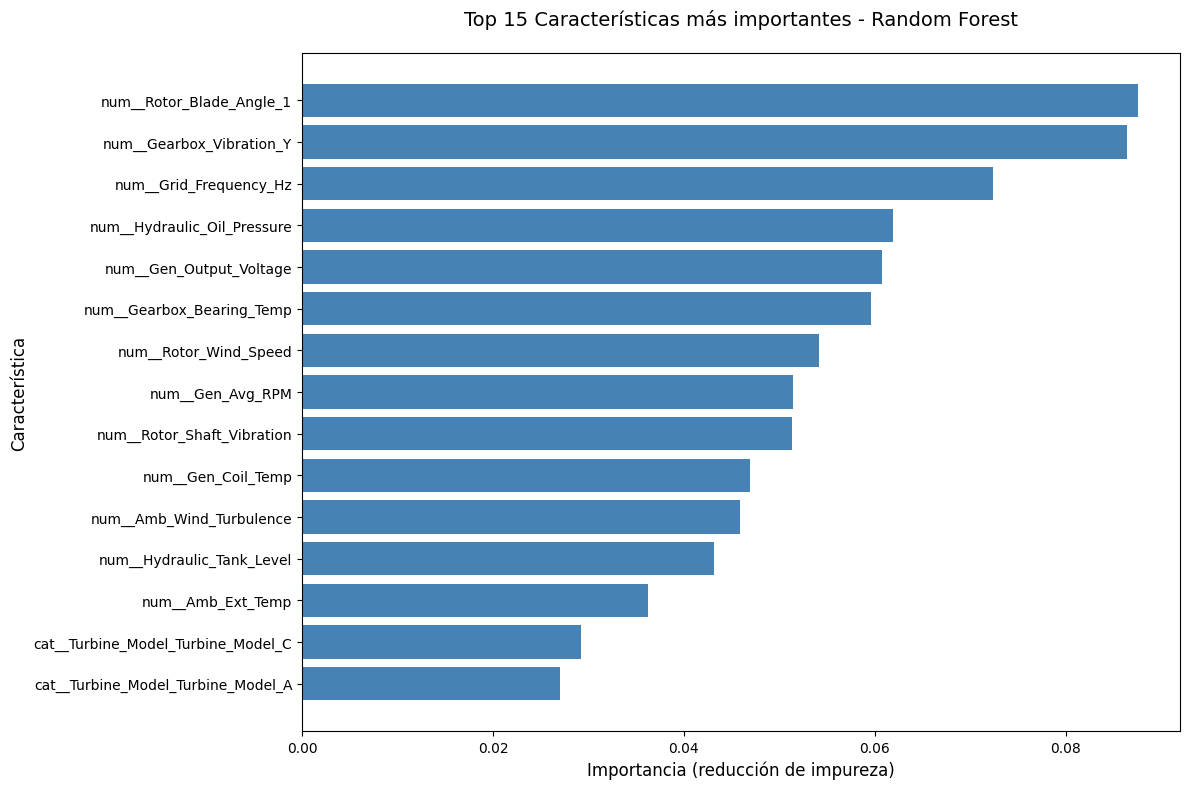


=== Importancia de todas las características ===

                                 Feature  Importance
                num__Rotor_Blade_Angle_1        0.09
                num__Gearbox_Vibration_Y        0.09
                  num__Grid_Frequency_Hz        0.07
             num__Hydraulic_Oil_Pressure        0.06
                 num__Gen_Output_Voltage        0.06
               num__Gearbox_Bearing_Temp        0.06
                   num__Rotor_Wind_Speed        0.05
                        num__Gen_Avg_RPM        0.05
              num__Rotor_Shaft_Vibration        0.05
                      num__Gen_Coil_Temp        0.05
                num__Amb_Wind_Turbulence        0.05
               num__Hydraulic_Tank_Level        0.04
                       num__Amb_Ext_Temp        0.04
      cat__Turbine_Model_Turbine_Model_C        0.03
      cat__Turbine_Model_Turbine_Model_A        0.03
             num__System_Efficiency_Calc        0.03
                 num__Hydraulic_Oil_Temp        

In [116]:
# Extraer importancias del modelo entrenado
rf_model = best_rf.named_steps['model']
feature_names = best_rf.named_steps['preprocessor'].get_feature_names_out()
importances = rf_model.feature_importances_

# Crear DataFrame para visualización
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Visualización de las 15 características más importantes
plt.figure(figsize=(12, 8))
top_features = feature_importance_df.head(15)
plt.barh(top_features['Feature'], top_features['Importance'], color='steelblue')
plt.xlabel('Importancia (reducción de impureza)', fontsize=12)
plt.ylabel('Característica', fontsize=12)
plt.title('Top 15 Características más importantes - Random Forest', fontsize=14, pad=20)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig(r'..\Visualizaciones\rf_feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

# Mostrar tabla completa ordenada
print("\n=== Importancia de todas las características ===\n")
print(feature_importance_df.to_string(index=False))

### **3.6. Análisis crítico: Comparación con modelos base**

#### **3.6.1. Comparación cuantitativa**

| Modelo | Accuracy | F1-macro | Recall Failure |
|--------|----------|----------|----------------|
| Logistic Regression | 0.608 | 0.591 | 0.562 |
| Arbol de Decision | 0.650 | 0.609 | 0.430 |
| KNN | 0.753 | 0.687 | 0.355 |
| Naive Bayes | 0.658 | 0.627 | 0.537 |
| **Random Forest** | **0.780** | **0.744** | **0.545** |

#### **3.6.2. ¿Logró RF una mejora sustancial, especialmente en las clases minoritarias?**

Sí. *Random Forest* supera a todos los modelos base en accuracy (+2.7% vs KNN) y F1-macro (+5.7% vs KNN). Para la clase *Failure*, el *recall* (0.545) mejora +53.5% respecto a KNN (0.355) y +26.7% respecto al Arbol de Decisión (0.430). Aunque no supera a *Logistic Regression* en *recall* puro, **Random Forest logra el mejor equilibrio precision-recall**, con un F1-score de 0.617 para Failure (vs 0.477 de Logistic Regression). En la clase *Warning*, el *recall* alcanza 0.796, el mejor de todos los modelos.

#### **3.6.3. Análisis de importancia de características:**

Las variables más relevantes son:
1. `Rotor_Blade_Angle_1` (0.09) y `Gearbox_Vibration_Y` (0.09)
2. `Grid_Frequency_Hz` (0.07)
3. `Hydraulic_Oil_Pressure`, `Gen_Output_Voltage`, `Gearbox_Bearing_Temp` (0.06)

#### **3.6.4. ¿Tiene sentido este resultado?**

Sí. Las variables de vibración, mecánicas y eléctricas son indicadores directos de fallos en turbinas. `Rotor_Blade_Angle_1` como variable más importante es coherente, ya que desviaciones en el ángulo de las palas reflejan problemas en el sistema de control. Las variables térmicas (`Gearbox_Bearing_Temp`, `Gen_Coil_Temp`) y de presión hidráulica confirman que el sobrecalentamiento y la presión inadecuada son precursores de fallo.

#### **3.6.5. ¿Identifica RF las variables categóricas como importantes?**

Sí, aunque con importancias individuales menores. `Turbine_Model_C` y `Turbine_Model_A` tienen importancia de 0.03 cada una. Si sumamos todas las categorías de `Turbine_Model` (0.03 + 0.03 + 0.01 + 0.01 = 0.08), su contribución agregada es comparable a las variables numéricas más relevantes. En cambio, `Installation_Region` tiene menor peso (suma total: 0.02), sugiriendo posiblemente que las variables ambientales numéricas ya capturan la información geográfica relevante.

## 4. Combinación paralela de clasificadores de base similar: Boosting (1.5 puntos)

<div style="background-color: #d9edf7; color: #31708f; padding: 10px; border: 1px solid #bce8f1; border-radius: 4px;">
<h4>Implementación:</h4>

1. Implementa `GradientBoostingClassifier`.
2. Realiza una búsqueda y ajuste (tuning) de hiperparámetros clave utilizando validación cruzada. Define un rango de búsqueda razonable para cada hiperparámetro y usa la métrica F1 seleccionada.
3. Reporta los mejores hiperparámetros encontrados y el score de validación cruzada obtenido con ellos.
   
</div>

### **4.1. Implementación de `GradientBoostingClassifier`**

*Gradient Boosting* es un método *ensemble* secuencial que construye modelos de forma iterativa, donde cada nuevo árbol intenta corregir los errores residuales de los anteriores. A diferencia de *Random Forest*, que reduce la varianza mediante el promedio de modelos independientes, *Gradient Boosting* reduce el sesgo mediante el aprendizaje secuencial enfocado en las instancias más difíciles.

In [118]:
gb = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', GradientBoostingClassifier(
        random_state=42
    ))
])

### **4.2. Búsqueda y ajuste de hiperparámetros con `GridSearchCV`**

Se realiza una búsqueda y ajuste (tuning) de hiperparámetros mediante validación cruzada de 5 particiones (5-CV), utilizando **F1-score macro** como métrica de optimización (la misma empleada para *Random Forest*, permitiendo una comparación justa).

Los hiperparámetros ajustados son:

* `n_estimators`: número de árboles secuenciales (*boosting rounds*).
* `learning_rate`: tasa de aprendizaje que controla la contribución de cada árbol (valores más bajos requieren más árboles pero mejoran la generalización).
* `max_depth`: profundidad máxima de cada árbol individual (árboles más profundos capturan interacciones más complejas).
* `subsample`: fracción de muestras usadas para entrenar cada árbol (introduce aleatoriedad y reduce sobreajuste).

In [119]:
param_grid_gb = {
    'model__n_estimators': [100, 200, 300],
    'model__learning_rate': [0.01, 0.1, 0.2],
    'model__max_depth': [3, 5, 7],
    'model__subsample': [0.8, 1.0]
}

grid_gb = GridSearchCV(
    gb,
    param_grid=param_grid_gb,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)

grid_gb.fit(X_train, y_train)

Fitting 5 folds for each of 54 candidates, totalling 270 fits


,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'model__learning_rate': [0.01, 0.1, ...], 'model__max_depth': [3, 5, ...], 'model__n_estimators': [100, 200, ...], 'model__subsample': [0.8, 1.0]}"
,scoring,'f1_macro'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('cat', ...), ('num', ...)]"


### **4.3. Mejores hiperparámetros y score de validación cruzada**

Los hiperparámetros óptimos muestran que:

* Un `learning_rate` moderado (0.2) proporciona el mejor equilibrio entre velocidad de convergencia y capacidad de generalización.
* 200 estimadores (`n_estimators`) son necesarios para capturar la complejidad del problema sin sobreajustar.
* `max_depth`=7 permite capturar interacciones entre variables sin crear árboles excesivamente complejos.
* `subsample`=0.8 introduce aleatoriedad que mejora la robustez del modelo.

El **F1-score macro** de validación cruzada (0.791) supera al obtenido por Random Forest (0.742), sugiriendo que el enfoque secuencial de *boosting* es más efectivo para este problema, especialmente en la corrección de errores en las clases minoritarias.


In [120]:
print("Mejores hiperparámetros:", grid_gb.best_params_)
print("Mejor F1-score macro (validación cruzada):", grid_gb.best_score_)

Mejores hiperparámetros: {'model__learning_rate': 0.2, 'model__max_depth': 7, 'model__n_estimators': 200, 'model__subsample': 0.8}
Mejor F1-score macro (validación cruzada): 0.7914461960689454


<div style="background-color: #d9edf7; color: #31708f; padding: 10px; border: 1px solid #bce8f1; border-radius: 4px;">
<h4>Implementación:</h4>

4. Valida (con el conjunto de datos de validación) el modelo final.
5. Muestra un gráfico de la importancia de las características de dicho modelo
6. **Análisis Crítico:** Compara el rendimiento de tu Gradient Boosting optimizado con los modelos anteriores. ¿Logró una mejora sustancial? Analiza tu gráfico de importancia de características: ¿Existen diferencias notables en el ranking o en las variables consideradas más importantes por los modelos boosting en comparación con Random Forest
   
</div>

### **4.4. Validación del Gradient Boosting final**

Una vez identificados los mejores hiperparámetros mediante validación cruzada, se entrena el modelo *Gradient Boosting* final sobre todo el conjunto de entrenamiento y se evalúa su rendimiento sobre el conjunto de test reservado.

In [121]:
# Entrenar el modelo final con los mejores hiperparámetros
best_gb = grid_gb.best_estimator_
y_pred_gb = best_gb.predict(X_test)

# Evaluación del modelo final
evaluate_model("Gradient Boosting (optimizado)", y_test, y_pred_gb)


Gradient Boosting (optimizado)
              precision    recall  f1-score   support

           0      0.839     0.906     0.871       298
           1      0.770     0.867     0.816       181
           2      0.865     0.529     0.656       121

    accuracy                          0.818       600
   macro avg      0.824     0.767     0.781       600
weighted avg      0.823     0.818     0.811       600



El modelo *Gradient Boosting* optimizado alcanza una `accuracy` de 0.818 y un **F1-score macro** de 0.781, superando a *Random Forest* (0.780 y 0.744 respectivamente). Destaca la precision excepcional de 0.865 en la clase *Failure*, aunque el *recall* (0.529) se mantiene similar al de *Random Forest* (0.545).

### **4.5. Importancia de las características del modelo final**

El gráfico muestra que `Gearbox_Vibration_Y` domina claramente con una importancia de 0.12, seguida de un grupo de variables con importancia de 0.07 cada una: `Rotor_Wind_Speed`, `Gen_Output_Voltage`, `Hydraulic_Oil_Pressure`, `Rotor_Blade_Angle_1` y `Grid_Frequency_Hz`.

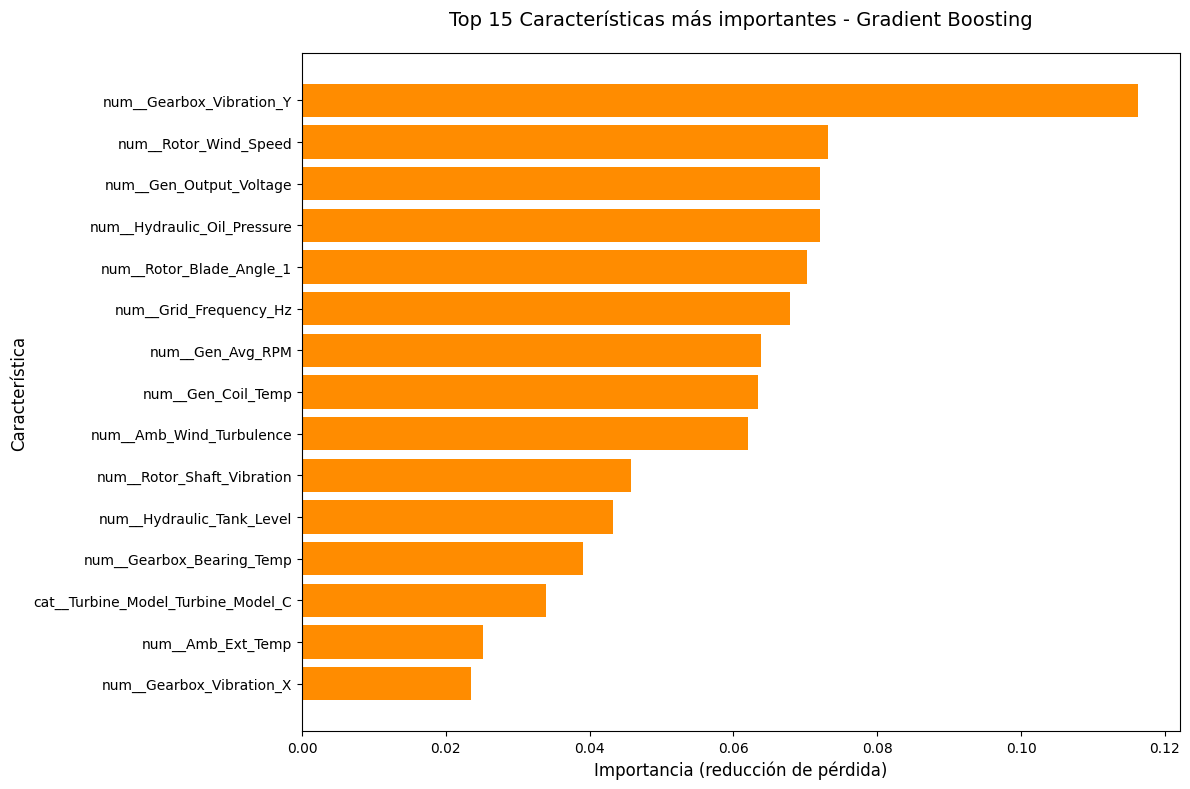


=== Importancia de todas las características ===

                                 Feature  Importance
                num__Gearbox_Vibration_Y        0.12
                   num__Rotor_Wind_Speed        0.07
                 num__Gen_Output_Voltage        0.07
             num__Hydraulic_Oil_Pressure        0.07
                num__Rotor_Blade_Angle_1        0.07
                  num__Grid_Frequency_Hz        0.07
                        num__Gen_Avg_RPM        0.06
                      num__Gen_Coil_Temp        0.06
                num__Amb_Wind_Turbulence        0.06
              num__Rotor_Shaft_Vibration        0.05
               num__Hydraulic_Tank_Level        0.04
               num__Gearbox_Bearing_Temp        0.04
      cat__Turbine_Model_Turbine_Model_C        0.03
                       num__Amb_Ext_Temp        0.03
                num__Gearbox_Vibration_X        0.02
             num__System_Efficiency_Calc        0.02
                       num__Amb_Humidity        

In [122]:
# Extraer importancias del modelo entrenado
gb_model = best_gb.named_steps['model']
feature_names = best_gb.named_steps['preprocessor'].get_feature_names_out()
importances_gb = gb_model.feature_importances_

# Crear DataFrame para visualización
feature_importance_gb_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances_gb
}).sort_values(by='Importance', ascending=False)

# Visualización de las 15 características más importantes
plt.figure(figsize=(12, 8))
top_features_gb = feature_importance_gb_df.head(15)
plt.barh(top_features_gb['Feature'], top_features_gb['Importance'], color='darkorange')
plt.xlabel('Importancia (reducción de pérdida)', fontsize=12)
plt.ylabel('Característica', fontsize=12)
plt.title('Top 15 Características más importantes - Gradient Boosting', fontsize=14, pad=20)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig(r'..\Visualizaciones\gb_feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

# Mostrar tabla completa ordenada
print("\n=== Importancia de todas las características ===\n")
print(feature_importance_gb_df.to_string(index=False))

### **4.6. Análisis Crítico: Comparación con modelos anteriores**

#### **4.6.1. Comparación cuantitativa:**

| Modelo | Accuracy | F1-macro | Recall Failure | Precision Failure |
|--------|----------|----------|----------------|-------------------|
| Logistic Regression | 0.608 | 0.591 | 0.562 | 0.415 |
| Decision Tree | 0.650 | 0.609 | 0.430 | 0.495 |
| KNN | 0.753 | 0.687 | 0.355 | 0.754 |
| Naive Bayes | 0.658 | 0.627 | 0.537 | 0.464 |
| Random Forest | 0.780 | 0.744 | 0.545 | 0.710 |
| **Gradient Boosting** | **0.818** | **0.781** | **0.529** | **0.865** |

#### **4.6.2. ¿Logró Gradient Boosting una mejora sustancial?**

Sí. Gradient Boosting supera a todos los modelos previos:

- **+3.8% en accuracy** respecto a *Random Forest* (0.818 vs 0.780).
- **+3.7% en F1-macro** respecto a *Random Forest* (0.781 vs 0.744).
- **Precision en Failure**: 0.865 (vs 0.710 de RF), mejorando +21.8% y reduciendo drásticamente los falsos positivos.

Sin embargo, el **recall de Failure (0.529)** es ligeramente inferior al de *Random Forest* (0.545), lo que indica que *Gradient Boosting* es más conservador al clasificar fallos críticos. A pesar de esto, el **F1-score de Failure alcanza 0.656** (vs 0.617 de RF), mostrando un mejor equilibrio global.

La mejora más notable está en la **clase Warning**: recall de 0.867 (vs 0.796 de RF) y F1-score de 0.816 (vs 0.776 de RF), confirmando que *boosting* es especialmente efectivo en clases intermedias donde los errores son más sutiles.

#### **4.6.3. Diferencias en la importancia de características:**

Comparando los rankings:

**Random Forest Top 5:**
1. Rotor_Blade_Angle_1 (0.09)
2. Gearbox_Vibration_Y (0.09)
3. Grid_Frequency_Hz (0.07)
4. Hydraulic_Oil_Pressure (0.06)
5. Gen_Output_Voltage (0.06)

**Gradient Boosting Top 5:**
1. Gearbox_Vibration_Y (0.12)
2. Rotor_Wind_Speed (0.07)
3. Gen_Output_Voltage (0.07)
4. Hydraulic_Oil_Pressure (0.07)
5. Rotor_Blade_Angle_1 (0.07)

#### **4.6.4. ¿Existen diferencias notables?**

Sí, diferencias significativas:

1. **Concentración de importancia**: *Gradient Boosting* asigna mucha más importancia a `Gearbox_Vibration_Y` (0.12 vs 0.09 de RF), identificándola como la variable claramente dominante. Esto refleja que el enfoque secuencial detecta que los errores residuales están fuertemente correlacionados con vibraciones anómalas en la caja de cambios.

2. **Cambio en el ranking**: `Rotor_Blade_Angle_1` pasa de ser la variable más importante en RF (0.09) a la quinta posición en GB (0.07). En su lugar, `Rotor_Wind_Speed` emerge como segunda más relevante (0.07), ausente del top 5 de RF.

3. **Mayor foco en variables mecánicas y operativas**: GB prioriza `Rotor_Wind_Speed` y `Gearbox_Vibration_Y`, mientras que RF daba más peso a variables de control como `Rotor_Blade_Angle_1` y `Grid_Frequency_Hz`.

4. **Convergencia en variables críticas**: Ambos modelos coinciden en que `Gen_Output_Voltage`, `Hydraulic_Oil_Pressure`, `Grid_Frequency_Hz` y `Rotor_Blade_Angle_1` son relevantes, aunque con diferente peso relativo.

5. **Variables categóricas**: `Turbine_Model_C` mantiene importancia moderada (0.03 en GB vs 0.03 en RF), pero el resto de variables categóricas tienen peso casi nulo en ambos modelos, confirmando que los sensores físicos capturan la mayor parte de la información predictiva.

La diferencia más relevante es que **Gradient Boosting identifica de forma más agresiva las variables que corrigen errores específicos** (especialmente vibraciones), mientras que *Random Forest* distribuye la importancia de forma más uniforme entre múltiples variables.

## 5. Combinación secuencial de clasificadores de base diferente: Stacking (1.5 punto)

<div style="background-color: #d9edf7; color: #31708f; padding: 10px; border: 1px solid #bce8f1; border-radius: 4px;">
<h4>Implementación:</h4>

1. Implementa `StackingClassifier`.
2. Utiliza los modelos base implementados en la sección 2 ¿Crees que esta combinación de modelos es diversa y adecuada para Stacking?
3. Elige un meta-clasificador. Puedes optar por usar los hiperparámetros por defecto o realizar un pequeño ajuste si lo consideras necesario.
4. Valida el `StackingClassifier` completo usando los datos de validación con la métrica F1 seleccionada. Reporta el score.
5. **Análisis Crítico:** Compara el rendimiento de tu Stacking model con el mejor resultado que obtuviste de un ensemble individual (RF o Boosting) en los pasos anteriores. ¿Aportó Stacking una mejora significativa del rendimiento en este dataset? Explica brevemente cómo crees que el meta-clasificador está utilizando las predicciones de tus base learners elegidos.
   
</div>

<div style="background-color: #f2dede; color: #a94442; padding: 10px; border: 1px solid #ebccd1; border-radius: 4px">
<h4>Solución:</h4>
</div>

In [110]:
#### USE TANTAS CELDAS COMO NECESITES ####

<div style="background-color: #dff0d8; color: #3c763d; padding: 10px; border: 1px solid #d6e9c6; border-radius: 4px;">
<h4>Análisis:</h4>  
    
**USA TANTAS CELDAS COMO NECESITES**
</div>

## 6. Combinación secuencial de clasificadores de base diferente: Cascading (1.5 puntos)

<div style="background-color: #d9edf7; color: #31708f; padding: 10px; border: 1px solid #bce8f1; border-radius: 4px;">
<h4>Implementación:</h4>

1. Combina en cascada los modelos base implementados en la sección 2. Ten en cuenta la definición presentada en el documento "Combinación de models - PID_00296757, Jordi Casas Roma y Julià Minguillón Alfonso" que se encuentra en los recursos de la asignatura. Explora un Stacking con `passthrough=True` ¿Crees que esta combinación de modelos es diversa y adecuada para Cascading?
2. Elige un meta-clasificador. Puedes optar por usar los hiperparámetros por defecto o realizar un pequeño ajuste si lo consideras necesario.
3. Valida tu clasificador en cascada completo usando los datos de validación con la métrica seleccionada. Reporta el score.
4. **Análisis Crítico:** Compara el rendimiento de tu modelo en cascada con el mejor resultado obtenido en los pasos anteriores. ¿Aportó Cascading una mejora significativa del rendimiento en este dataset? ¿Observaste alguna ventaja en términos de eficiencia computacional?.
   
</div>

<div style="background-color: #f2dede; color: #a94442; padding: 10px; border: 1px solid #ebccd1; border-radius: 4px">
<h4>Solución:</h4>
</div>

In [111]:
#### USE TANTAS CELDAS COMO NECESITES ####

<div style="background-color: #dff0d8; color: #3c763d; padding: 10px; border: 1px solid #d6e9c6; border-radius: 4px;">
<h4>Análisis:</h4>  
    
**USA TANTAS CELDAS COMO NECESITES**
</div>

## 7. Alternativa: Balanced Random Forest (1 punto)

El BalancedRandomForestClassifier es una variante del algoritmo de ensamble Random Forest diseñada específicamente para abordar problemas de clasificación con clases severamente desbalanceadas sin necesidad de pre-procesamiento externo (como SMOTE).

Mecanismo de Funcionamiento: La diferencia fundamental respecto al Random Forest estándar reside en la etapa de construcción de cada árbol de decisión individual (proceso de bootstrapping):

Submuestreo Dinámico: Para entrenar cada árbol del bosque, el algoritmo genera un subconjunto de datos temporal. En este paso, realiza un submuestreo aleatorio (random undersampling) de la clase mayoritaria para igualar el número de instancias de la clase minoritaria.

Entrenamiento Equilibrado: Como resultado, cada árbol individual se entrena con un dataset perfectamente balanceado (ratio 1:1), aunque el dataset original esté descompensado.

Agregación: Finalmente, el modelo combina las predicciones de todos los árboles (que han visto diferentes subconjuntos equilibrados de la clase mayoritaria) mediante votación para generar la predicción final.

Ventaja Principal: Permite aprovechar la robustez del bagging (reducción de varianza) mientras mitiga el sesgo hacia la clase mayoritaria de forma nativa, explorando una mayor variedad de datos de la clase mayoritaria a través de los múltiples árboles.

<div style="background-color: #d9edf7; color: #31708f; padding: 10px; border: 1px solid #bce8f1; border-radius: 4px;">
<h4>Implementación:</h4>

1. Implementa `BalancedRandomForestClassifier` de la librería `imblearn`.
2. Entrena y valida el clasificador completo usando la métrica seleccionada. Reporta el score.
5. **Análisis Crítico:** Compara el rendimiento de este modelo con los anteriores. ¿dirías que este modelo es más "inteligente" o simplemente más "agresivo" disparando alarmas?.
</div>

<div style="background-color: #f2dede; color: #a94442; padding: 10px; border: 1px solid #ebccd1; border-radius: 4px">
<h4>Solución:</h4>
</div>

In [112]:
#### USE TANTAS CELDAS COMO NECESITES ####

<div style="background-color: #dff0d8; color: #3c763d; padding: 10px; border: 1px solid #d6e9c6; border-radius: 4px;">
<h4>Análisis:</h4>  
    
**USA TANTAS CELDAS COMO NECESITES**
</div>

## 8. Ajuste del Umbral de Decisión (1 punto)



<div style="background-color: #d9edf7; color: #31708f; padding: 10px; border: 1px solid #bce8f1; border-radius: 4px;">
<h4>Implementación:</h4>

Si tenemos en cuenta que la rotura de una turbina equivale a una pérdida de 50.000€ y que el coste de inspección de la turbina es de 200€, es preferible que el sistema active alarmas aunque algunas sean falsas a que ignore fallos reales. Por defecto, un clasificador decide que algo es un "Fallo" si la probabilidad calculada es mayor que el 50\%. ¿Qué pasa si bajamos esa exigencia?

Con ayuda de cuaquier modelo de IA generativa, prioriza drásticamente la seguridad (Recall). Tu objetivo concreto es ajustar la lógica de decisión del modelo para alcanzar un Recall mínimo del 80% en la Clase 2 (Fallo Crítico).

Deberás pedirle a la IA que te explique cómo manipular el umbral de decisión (threshold) a partir de las probabilidades predichas para lograr este objetivo sin modificar el modelo ni reentrenarlo. Genera el nuevo reporte de clasificación y analiza: ¿A qué precio (en términos de Precisión) has conseguido esta seguridad?
   
</div>

<div style="background-color: #f2dede; color: #a94442; padding: 10px; border: 1px solid #ebccd1; border-radius: 4px">
<h4>Solución:</h4>
</div>

In [113]:
#### USE TANTAS CELDAS COMO NECESITES ####

<div style="background-color: #dff0d8; color: #3c763d; padding: 10px; border: 1px solid #d6e9c6; border-radius: 4px;">
<h4>Análisis:</h4>  
    
**USA TANTAS CELDAS COMO NECESITES**
</div>